# Evaluación de negocio para Olist Brazilian E-commerce
## Ana Luzia Ferrer Mendez

## Metodología CRISP-DM
### 1. Entendimiento del negocio
Olist es una plataforma brasileña de e-commerce que permite a vendedores independientes concretar ventas a través de todo el país. Tienen datasets de más de 100 mil pedidos y necesitan entender el comportamiento de estos en tres dimensiones: logística, comercial y de satisfacción del cliente, y entender qué están haciendo mal o bien, y por consiguiente ajustar sus decisiones y aplicar estrategias para mejorar dichas dimensiones.

Por esto, se plantea la siguiente pregunta central: ¿Qué factores logísticos determinan la satisfacción del cliente en Olist, qué segmentos geográficos concentran el mayor riesgo, y qué tan sostenible es esa operación bajo escenarios de crecimiento?

Los datasets utilizados, entonces:
- olist_orders_dataset.csv: porque contiene información sobre la logística de entregas con los tiempos asociados a un pedido: fechas de compra, aprobación del pago, despacho del vendedor, entrega estimada y real.
- olist_order_items_dataset.csv: contiene información de valor de flete, que sirve para estimar costos de logística.
- olist_order_reviews_dataset.csv: contiene información de satisfacción del cliente con su pedido.
- olist_customers_dataset.csv y olist_geolocation_dataset.csv: información necesaria para hacer análisis geográfico.

### 2. Entendimiento de los datos

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

orders    = pd.read_csv("olist_orders_dataset.csv")
items     = pd.read_csv("olist_order_items_dataset.csv")
reviews   = pd.read_csv("olist_order_reviews_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
geo       = pd.read_csv("olist_geolocation_dataset.csv")
products  = pd.read_csv("olist_products_dataset.csv")

archivos = {
    "orders": orders, "items": items, "reviews": reviews,
    "customers": customers, "geo": geo,
}

for nombre, df in archivos.items():
    nulos = df.isnull().sum().sum()
    pct   = nulos / df.size * 100
    print(f"{nombre:12s} → {df.shape[0]:>7,} filas | {df.shape[1]:>2} cols | "
          f"nulos: {nulos:>6,} ({pct:.1f}%)")

orders       →  99,441 filas |  8 cols | nulos:  4,908 (0.6%)
items        → 112,650 filas |  7 cols | nulos:      0 (0.0%)
reviews      →  99,224 filas |  7 cols | nulos: 145,903 (21.0%)
customers    →  99,441 filas |  5 cols | nulos:      0 (0.0%)
geo          → 1,000,163 filas |  5 cols | nulos:      0 (0.0%)


#### Revisión de nulos

Hay cierto porcentaje de nulos en 3 de los datasets. Se revisa uno por uno para saber qué variables lo están causando, y además, se revisan tipos de datos.

Para saber qué tipos de datos corresponden a cada variable y la lógica de los nulos, además de entender qué significa cada una, se hace un diccionario de variables por dataset.

##### olist_orders_dataset.csv
- **order_id**: Identificador único de la orden.
- **customer_id**: Identificador del cliente asociado a la orden.
- **order_status**: Estado del pedido (delivered, canceled, shipped, etc.).
- **order_purchase_timestamp**: Fecha y hora en que el cliente realizó la compra.
- **order_approved_at**: Fecha de aprobación del pago por la plataforma.
- **order_delivered_carrier_date**: Fecha en que el paquete fue entregado al transportista.
- **order_delivered_customer_date**: Fecha real de entrega al cliente.
- **order_estimated_delivery_date**: Fecha de entrega prometida al cliente al momento de la compra.

##### olist_order_items_dataset.csv
- **order_id**: Llave foránea que vincula el ítem con su orden.
- **order_item_id**: Número secuencial del ítem dentro de la orden.
- **product_id**: Identificador del producto.
- **seller_id**: Identificador del vendedor que despacha el ítem.
- **shipping_limit_date**: Fecha límite comprometida con el vendedor para hacer el despacho.
- **price**: Precio unitario del producto en BRL.
- **freight_value**: Costo de flete cobrado al cliente por el ítem en BRL.

##### olist_order_reviews_dataset.csv
- **review_id**: Identificador único de la reseña.
- **order_id**: Llave foránea que vincula la reseña con su orden.
- **review_score**: Calificación del cliente de 1 (muy insatisfecho) a 5 (muy satisfecho).
- **review_comment_title**: Título corto del comentario escrito por el cliente (en portugués).
- **review_comment_message**: Texto libre del comentario (en portugués).
- **review_creation_date**: Fecha en que se generó la encuesta de satisfacción.
- **review_answer_timestamp**: Fecha y hora en que el cliente respondió la encuesta.

##### olist_customers_dataset.csv
- **customer_id**: Identificador de instancia de compra (puede repetirse si el cliente compró varias veces).
- **customer_unique_id**: Identificador real del cliente a lo largo del tiempo.
- **customer_zip_code_prefix**: Primeros 5 dígitos del código postal (CEP) del cliente.
- **customer_city**: Ciudad del cliente.
- **customer_state**: Estado brasileño del cliente.

##### olist_geolocation_dataset.csv
- **geolocation_zip_code_prefix**: Primeros 5 dígitos del CEP. Puede tener múltiples registros por código.
- **geolocation_lat**: Latitud geográfica asociada al CEP.
- **geolocation_lng**: Longitud geográfica asociada al CEP.
- **geolocation_city**: Ciudad asociada al CEP.
- **geolocation_state**: Estado asociado al CEP.

##### olist_products_dataset.csv
- **product_id**: Identificador único del producto.
- **product_category_name**: Categoría del producto en portugués.
- **product_name_lenght**: Número de caracteres en el nombre del producto.
- **product_description_lenght**: Número de caracteres en la descripción del producto.
- **product_photos_qty**: Cantidad de fotografías en el listado del producto.
- **product_weight_g**: Peso del producto en gramos.
- **product_length_cm**: Longitud del producto en centímetros.
- **product_height_cm**: Altura del producto en centímetros.
- **product_width_cm**: Ancho del producto en centímetros.

In [108]:
# Revisa tipos de dato y nulos por columna en cada archivo
for nombre, df in archivos.items():
    print(f"\n{'='*55}")
    print(f"  {nombre.upper()}")
    print(f"{'='*55}")
    print(df.dtypes.to_frame("dtype").join(
        df.isnull().sum().to_frame("nulos")
    ))


  ORDERS
                                dtype  nulos
order_id                       object      0
customer_id                    object      0
order_status                   object      0
order_purchase_timestamp       object      0
order_approved_at              object    160
order_delivered_carrier_date   object   1783
order_delivered_customer_date  object   2965
order_estimated_delivery_date  object      0

  ITEMS
                       dtype  nulos
order_id              object      0
order_item_id          int64      0
product_id            object      0
seller_id             object      0
shipping_limit_date   object      0
price                float64      0
freight_value        float64      0

  REVIEWS
                          dtype  nulos
review_id                object      0
order_id                 object      0
review_score              int64      0
review_comment_title     object  87656
review_comment_message   object  58247
review_creation_date     object      0
revi

In [109]:
# Verificación: ¿los nulos en fechas corresponden a órdenes no entregadas?
print(orders[orders["order_delivered_customer_date"].isnull()]["order_status"].value_counts())
# Esperado: shipped, canceled, processing — ninguna 'delivered'

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64


In [110]:
# Inspeccionar las 8 órdenes anómalas
anomalas = orders[
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_customer_date"].isnull())
]
print(anomalas[["order_id", "order_status", 
                "order_delivered_carrier_date",
                "order_delivered_customer_date",
                "order_estimated_delivery_date"]])

                               order_id order_status  \
3002   2d1e2d5bf4dc7227b3bfebb81328c15f    delivered   
20618  f5dd62b788049ad9fc0526e3ad11a097    delivered   
43834  2ebdfc4f15f23b91474edf87475f108e    delivered   
79263  e69f75a717d64fc5ecdfae42b2e8e086    delivered   
82868  0d3268bad9b086af767785e3f0fc0133    delivered   
92643  2d858f451373b04fb5c984a1cc2defaf    delivered   
97647  ab7c89dc1bf4a1ead9d6ec1ec8968a84    delivered   
98038  20edc82cf5400ce95e1afacc25798b31    delivered   

      order_delivered_carrier_date order_delivered_customer_date  \
3002           2017-11-30 18:12:23                           NaN   
20618          2018-06-25 08:05:00                           NaN   
43834          2018-07-03 13:57:00                           NaN   
79263          2018-07-03 13:57:00                           NaN   
82868          2018-07-03 09:28:00                           NaN   
92643                          NaN                           NaN   
97647          2018

Lógica de los nulos:

- orders 

order_approved_at con 160 nulos: órdenes cuyo pago nunca fue aprobado (canceladas antes de aprobación).

order_delivered_carrier_date con 1783 nulos: órdenes que nunca salieron del vendedor.

order_delivered_customer_date con 2965 nulos: órdenes que nunca llegaron al cliente.

    Hay 8 órdenes con status delivered pero sin fecha de entrega. Eso es una inconsistencia en los datos porque una orden marcada como entregada debería tener order_delivered_customer_date. El tratamiento es eliminarlos, ya que es una porción pequeña del dataset.

- reviews

review_comment_title con 87656 nulos (87%): el cliente no escribió título. Es opcional.

review_comment_message con 58247 nulos (58%): el cliente no escribió comentario. Es opcional.

    El tratamiento dependerá del uso posterior: no se realiza si se determina que no son columnas necesarias para el análisis.

In [111]:
orders_clean = orders[
    ~((orders["order_status"] == "delivered") &
      (orders["order_delivered_customer_date"].isnull()))
].copy()

print(f"Órdenes antes:  {len(orders):,}")
print(f"Órdenes después: {len(orders_clean):,}")
print(f"Eliminadas:      {len(orders) - len(orders_clean)}")

Órdenes antes:  99,441
Órdenes después: 99,433
Eliminadas:      8


In [112]:
# Verificar que los 610 nulos son exactamente las mismas filas
cols_bloque = ["product_category_name", "product_name_lenght",
               "product_description_lenght", "product_photos_qty"]
print(products[cols_bloque].isnull().sum())
print("¿Mismo bloque?", products[cols_bloque].isnull().apply(
    lambda col: col.equals(products["product_category_name"].isnull())
).all())

# Verificar que los 2 nulos en dimensiones son filas distintas a los 610
mask_dim = products["product_weight_g"].isnull()
mask_cat = products["product_category_name"].isnull()
print("¿Solapan los 2 nulos con los 610?", (mask_dim & mask_cat).sum())

product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
dtype: int64
¿Mismo bloque? True
¿Solapan los 2 nulos con los 610? 1


- products

Los 610 nulos aparecen exactamente en las mismas filas en product_category_name, product_name_lenght, product_description_lenght y product_photos_qty. Son los mismos 610 productos sin ficha registrada.

product_weight_g, product_length_cm, product_height_cm, product_width_cm tienen solo 2 nulos, es decir, productos distintos, probablemente un error de carga puntual.

Se llenan los NaN de los 610 productos como "sin_categoria" y los otros dos nulos se eliminan.

In [113]:
# Eliminar los 2 productos con nulos en dimensiones físicas
products_clean = products.dropna(subset=["product_weight_g"])

print(f"Productos antes: {len(products):,}")
print(f"Productos después: {len(products_clean):,}")
print(f"Eliminados: {len(products) - len(products_clean)}")

Productos antes: 32,951
Productos después: 32,949
Eliminados: 2


In [114]:
products_clean = products.dropna(subset=["product_weight_g"]).copy()

products_clean["product_category_name"] = (
    products_clean["product_category_name"].fillna("sin_categoria")
)

#### Corrección de tipos de datos en fechas

In [115]:
# orders
cols_fecha_orders = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in cols_fecha_orders:
    orders_clean[col] = pd.to_datetime(orders_clean[col])

# items
items["shipping_limit_date"] = pd.to_datetime(items["shipping_limit_date"])

# reviews
reviews["review_creation_date"]    = pd.to_datetime(reviews["review_creation_date"])
reviews["review_answer_timestamp"] = pd.to_datetime(reviews["review_answer_timestamp"])

# Verificación
print(orders_clean.dtypes)

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [116]:
print("=== COBERTURA RELACIONAL ===\n")

# order_id
print("order_id:")
print(f"  orders:  {orders_clean['order_id'].nunique():,}")
print(f"  items:   {items['order_id'].nunique():,} — "
      f"{items['order_id'].isin(orders_clean['order_id']).mean()*100:.1f}% en orders")
print(f"  reviews: {reviews['order_id'].nunique():,} — "
      f"{reviews['order_id'].isin(orders_clean['order_id']).mean()*100:.1f}% en orders")

# customer_id
print("\ncustomer_id:")
print(f"  orders:    {orders_clean['customer_id'].nunique():,}")
print(f"  customers: {customers['customer_id'].nunique():,} — "
      f"{orders_clean['customer_id'].isin(customers['customer_id']).mean()*100:.1f}% match")

# CEP → geolocation
print("\nCEP clientes cubiertos por geolocation:")
cep_match = customers['customer_zip_code_prefix'].isin(
    geo['geolocation_zip_code_prefix']
).mean()*100
print(f"  {cep_match:.1f}%")

# seller_id
print("\nseller_id:")
print(f"  items:   {items['seller_id'].nunique():,}")

# product_id
print("\nproduct_id:")
print(f"  items:    {items['product_id'].nunique():,}")
print(f"  products: {products_clean['product_id'].nunique():,} — "
      f"{items['product_id'].isin(products_clean['product_id']).mean()*100:.1f}% match")

=== COBERTURA RELACIONAL ===

order_id:
  orders:  99,433
  items:   98,666 — 100.0% en orders
  reviews: 98,673 — 100.0% en orders

customer_id:
  orders:    99,433
  customers: 99,441 — 100.0% match

CEP clientes cubiertos por geolocation:
  99.7%

seller_id:
  items:   3,095

product_id:
  items:    32,951
  products: 32,949 — 100.0% match


Los cruces entre archivos son prácticamente perfectos: order_id, customer_id, seller_id y product_id presentan 100% de coincidencia entre tablas. El 99.7% de los CEP de clientes tiene coordenadas en geolocation

In [117]:
print("=== DISTRIBUCIÓN DE VARIABLES CLAVE ===\n")

# Precios y fletes
print("price (BRL):")
print(items["price"].describe().round(2))

print("\nfreight_value (BRL):")
print(items["freight_value"].describe().round(2))

# Valores anómalos
print(f"\nPrecios == 0:         {(items['price'] == 0).sum()}")
print(f"Fletes == 0:          {(items['freight_value'] == 0).sum()}")
print(f"Fletes negativos:     {(items['freight_value'] < 0).sum()}")

# Review score
print("\nreview_score:")
print(reviews["review_score"].value_counts().sort_index())
print(f"Media: {reviews['review_score'].mean():.2f}")

=== DISTRIBUCIÓN DE VARIABLES CLAVE ===

price (BRL):
count    112650.00
mean        120.65
std         183.63
min           0.85
25%          39.90
50%          74.99
75%         134.90
max        6735.00
Name: price, dtype: float64

freight_value (BRL):
count    112650.00
mean         19.99
std          15.81
min           0.00
25%          13.08
50%          16.26
75%          21.15
max         409.68
Name: freight_value, dtype: float64

Precios == 0:         0
Fletes == 0:          383
Fletes negativos:     0

review_score:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64
Media: 4.09


Se identificaron 383 ítems (0.34% del total) con freight_value == 0. El patrón sugiere envío gratis por promoción (precios entre 50–110 BRL, flete exactamente cero). Se eliminan para no obstaculizar la posterior aplicación de técnicas.

In [118]:
items_clean = items[items["freight_value"] > 0].copy()

print(f"Ítems antes:  {len(items):,}")
print(f"Ítems después: {len(items_clean):,}")
print(f"Eliminados:    {len(items) - len(items_clean)}")

Ítems antes:  112,650
Ítems después: 112,267
Eliminados:    383


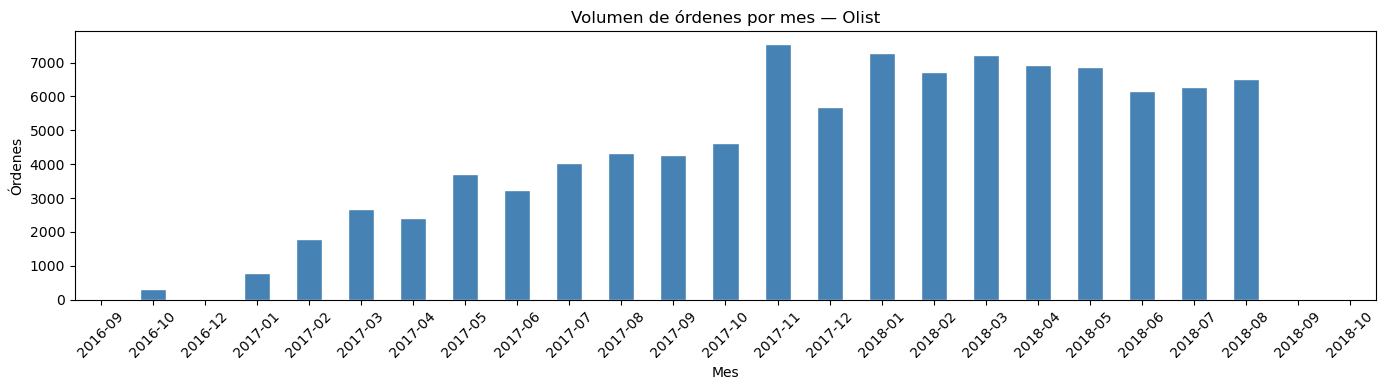

Período: 2016-09-04 → 2018-10-17

Meses con < 100 órdenes (posiblemente incompletos):
order_purchase_timestamp
2016-09     4
2016-12     1
2018-09    16
2018-10     4
Freq: M, dtype: int64


In [119]:
import matplotlib.pyplot as plt

ordenes_mes = (
    orders_clean
    .groupby(orders_clean["order_purchase_timestamp"].dt.to_period("M"))
    .size()
)

plt.figure(figsize=(14, 4))
ordenes_mes.plot(kind="bar", color="steelblue", edgecolor="white")
plt.title("Volumen de órdenes por mes — Olist")
plt.xlabel("Mes")
plt.ylabel("Órdenes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Período: {orders_clean['order_purchase_timestamp'].min().date()} "
      f"→ {orders_clean['order_purchase_timestamp'].max().date()}")
print(f"\nMeses con < 100 órdenes (posiblemente incompletos):")
print(ordenes_mes[ordenes_mes < 100])

Cuatro meses presentan volúmenes anómalos: septiembre 2016 (4 órdenes), diciembre 2016 (1), septiembre 2018 (16) y octubre 2018 (4). Corresponden al inicio y cierre del período de registro. Se excluyen del análisis temporal y de la simulación Monte Carlo para evitar sesgar la distribución de demanda mensual.

In [120]:
print("=== CARDINALIDAD ===\n")

print(f"Estados (customers):           {customers['customer_state'].nunique()}")
print(f"Ciudades (customers):          {customers['customer_city'].nunique():,}")
print(f"Categorías de producto:        {products_clean['product_category_name'].nunique()}")

print("\nTop 5 estados por volumen de órdenes:")
print(orders_clean.merge(customers, on="customer_id")["customer_state"]
      .value_counts().head())

print("\nTop 5 categorías por volumen de ítems:")
print(items.merge(products_clean, on="product_id")["product_category_name"]
      .value_counts().head())

=== CARDINALIDAD ===

Estados (customers):           27
Ciudades (customers):          4,119
Categorías de producto:        74

Top 5 estados por volumen de órdenes:
customer_state
SP    41739
RJ    12852
MG    11635
RS     5465
PR     5045
Name: count, dtype: int64

Top 5 categorías por volumen de ítems:
product_category_name
cama_mesa_banho           11115
beleza_saude               9670
esporte_lazer              8641
moveis_decoracao           8334
informatica_acessorios     7827
Name: count, dtype: int64


El estado de São Paulo concentra el 42% de las órdenes (41.739 de 99.433). Los cinco estados con mayor volumen (SP, RJ, MG, RS, PR) representan el 76% del total. Esta concentración justifica el clustering geográfico y la comparación de distribuciones regionales en MLE.

### 3. Preparación de los datos

Se procede a realizar la creación de variables adicionales con base en las existentes para enriquecer el análisis.

In [121]:
# Variables de logística
orders_clean["horas_entrega"] = (
    orders_clean["order_delivered_customer_date"] -
    orders_clean["order_delivered_carrier_date"]
).dt.total_seconds() / 3600

orders_clean["horas_retraso"] = (
    orders_clean["order_delivered_customer_date"] -
    orders_clean["order_estimated_delivery_date"]
).dt.total_seconds() / 3600

orders_clean["entrega_tardía"] = orders_clean["horas_retraso"] > 0

print(orders_clean[["horas_entrega","horas_retraso","entrega_tardía"]].describe().round(2))
print(f"\nEntregas tardías: {orders_clean['entrega_tardía'].sum():,} "
      f"({orders_clean['entrega_tardía'].mean()*100:.1f}%)")

       horas_entrega  horas_retraso
count       96475.00       96476.00
mean          223.93        -268.30
std           210.24         244.47
min          -386.31       -3504.39
25%            98.40        -389.87
50%           170.39        -286.77
75%           288.70        -153.36
max          4924.58        4535.40

Entregas tardías: 7,827 (7.9%)


horas_entrega es la diferencia entre la fecha de entrega al cliente y la fecha en la que el vendedor entregó el paquete al transportista, entonces, es el total de horas que el pedido demoró en llegar.

horas_retraso es la diferencia entre la fecha prometida al cliente (order_estimated_delivery_date) de la fecha real de entrega. Si el resultado es positivo, la orden llegó tarde. Si es negativo, llegó antes.

entrega_tardía es horas_retraso > 0 convertido a booleano (True/False).

In [122]:
items_agg = items_clean.groupby("order_id").agg(
    precio_total  = ("price", "sum"),
    flete_total   = ("freight_value", "sum"),
    num_items     = ("order_item_id", "count")
).reset_index()

items_agg["freight_ratio"] = (
    items_agg["flete_total"] /
    (items_agg["precio_total"] + items_agg["flete_total"])
)

print(items_agg[["precio_total","flete_total","freight_ratio","num_items"]]
      .describe().round(3))

       precio_total  flete_total  freight_ratio  num_items
count     98328.000    98328.000      98328.000  98328.000
mean        137.844       22.902          0.210      1.142
std         210.974       21.647          0.125      0.539
min           0.850        5.700          0.004      1.000
25%          45.900       13.920          0.117      1.000
50%          86.500       17.210          0.183      1.000
75%         149.900       24.110          0.276      1.000
max       13440.000     1794.960          0.955     21.000


precio_total y flete_total calcula el total de precio de productos y valor de flete para cada orden, ya que cada orden puede tener múltiples items.

freight_ratio divide el flete total entre el valor total del pedido (precio + flete). Da un número entre 0 y 1 que representa qué proporción del gasto del cliente fue solo envío. 

In [123]:
reviews_clean = (
    reviews.sort_values("review_answer_timestamp", ascending=False)
           .drop_duplicates(subset="order_id")
           [["order_id","review_score"]]
).copy()

reviews_clean["calificacion_baja"] = reviews_clean["review_score"] <= 2

print(f"Órdenes con reseña: {len(reviews_clean):,}")
print(f"Calificaciones bajas: {reviews_clean['calificacion_baja'].sum():,} "
      f"({reviews_clean['calificacion_baja'].mean()*100:.1f}%)")

Órdenes con reseña: 98,673
Calificaciones bajas: 14,494 (14.7%)


calificacion_baja funciona para convertir review_score en booleano: True si la calificación fue 1 o 2. 

In [124]:
print(f"Total registros geo: {len(geo):,}")
print(f"\nLat — min: {geo['geolocation_lat'].min():.4f} | max: {geo['geolocation_lat'].max():.4f}")
print(f"Lng — min: {geo['geolocation_lng'].min():.4f} | max: {geo['geolocation_lng'].max():.4f}")

# Cuántos están fuera del bounding box de Brasil
fuera = geo[
    ~(geo["geolocation_lat"].between(-33.8, 5.3)) |
    ~(geo["geolocation_lng"].between(-73.9, -32.4))
]
print(f"\nRegistros fuera de Brasil: {len(fuera):,} ({len(fuera)/len(geo)*100:.2f}%)")
print(fuera[["geolocation_lat","geolocation_lng","geolocation_city","geolocation_state"]].head(10))

Total registros geo: 1,000,163

Lat — min: -36.6054 | max: 45.0659
Lng — min: -101.4668 | max: 121.1054

Registros fuera de Brasil: 31 (0.00%)
        geolocation_lat  geolocation_lng         geolocation_city  \
387565        28.008978       -15.536867  bom retiro da esperanca   
513631        41.614052        -8.411675      vila nova de campos   
513643       -34.586422       -58.732101              santa maria   
513754        42.439286        13.820214              santa maria   
514429        38.381672        -6.328200                   raposo   
516682        43.684961        -7.411080                  portela   
538512        29.409252       -98.484121   santo antônio do canaã   
538557        21.657547      -101.466766   santo antonio do canaa   
585242        25.995203       -98.078544       santana do paraíso   
585260        25.995245       -98.078533       santana do paraiso   

       geolocation_state  
387565                SP  
513631                RJ  
513643          

Se identificaron 31 registros en geolocation con coordenadas fuera del territorio brasileño (0.003% del total), correspondientes a ciudades brasileñas con coordenadas erróneas asignadas a España, Portugal, Argentina, Italia y Texas. Se eliminan aplicando filtro de los límites de coordenadas de Brasil (lat: -33.8 a 5.3 / lng: -73.9 a -32.4)

In [125]:
# Filtrar coordenadas fuera de Brasil
geo_brasil = geo[
    (geo["geolocation_lat"].between(-33.8, 5.3)) &
    (geo["geolocation_lng"].between(-73.9, -32.4))
].copy()

geo_agg = geo_brasil.groupby("geolocation_zip_code_prefix").agg(
    lat = ("geolocation_lat", "mean"),
    lng = ("geolocation_lng", "mean")
).reset_index()

customers_geo = customers.merge(
    geo_agg,
    left_on  = "customer_zip_code_prefix",
    right_on = "geolocation_zip_code_prefix",
    how      = "left"
)

print(f"Clientes con coordenadas: {customers_geo['lat'].notna().sum():,} "
      f"de {len(customers_geo):,} "
      f"({customers_geo['lat'].notna().mean()*100:.1f}%)")

Clientes con coordenadas: 99,162 de 99,441 (99.7%)


Cada código postal puede tener múltiples registros en geolocation con coordenadas ligeramente distintas. Promediamos para obtener un único punto representativo por CEP antes de cruzar con customers. Cruzamos por customer_zip_code_prefix para asignarle coordenadas a cada cliente

In [126]:
# Tabla maestra
master = (
    orders_clean
    .merge(items_agg,     on="order_id",    how="left")
    .merge(reviews_clean, on="order_id",    how="left")
    .merge(customers_geo, on="customer_id", how="left")
)

master_clean = master.dropna(subset=[
    "horas_entrega", "horas_retraso",
    "review_score", "lat", "lng"
]).copy()

master_clean = master_clean[master_clean["horas_entrega"] > 0].copy()

print(f"Tabla maestra: {len(master_clean):,} filas | {master_clean.shape[1]} columnas")
print(f"Pérdida total: {len(orders_clean) - len(master_clean):,} filas "
      f"({(1 - len(master_clean)/len(orders_clean))*100:.1f}%)")
print(f"\nColumnas: {list(master_clean.columns)}")

Tabla maestra: 95,533 filas | 24 columnas
Pérdida total: 3,900 filas (3.9%)

Columnas: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'horas_entrega', 'horas_retraso', 'entrega_tardía', 'precio_total', 'flete_total', 'num_items', 'freight_ratio', 'review_score', 'calificacion_baja', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'geolocation_zip_code_prefix', 'lat', 'lng']


### 4. Modelado

¿Qué distribución de probabilidad describe mejor el tiempo de entrega real (días entre despacho y entrega), y varía esa distribución según región o categoría de producto?

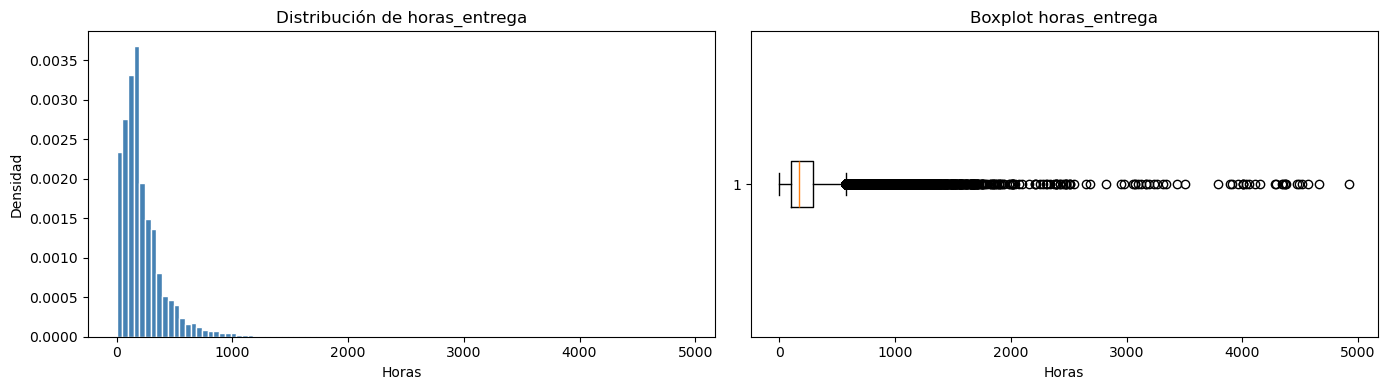

Asimetría (skewness): 4.514
Curtosis:             52.708
Percentil 95:         577.9 horas
Percentil 99:         980.3 horas


In [127]:
import matplotlib.pyplot as plt
import scipy.stats as stats

entrega = master_clean["horas_entrega"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma
axes[0].hist(entrega, bins=100, color="steelblue", edgecolor="white", density=True)
axes[0].set_title("Distribución de horas_entrega")
axes[0].set_xlabel("Horas")
axes[0].set_ylabel("Densidad")

# Boxplot
axes[1].boxplot(entrega, vert=False)
axes[1].set_title("Boxplot horas_entrega")
axes[1].set_xlabel("Horas")

plt.tight_layout()
plt.show()

print(f"Asimetría (skewness): {entrega.skew():.3f}")
print(f"Curtosis:             {entrega.kurt():.3f}")
print(f"Percentil 95:         {entrega.quantile(0.95):.1f} horas")
print(f"Percentil 99:         {entrega.quantile(0.99):.1f} horas")

La distribución tiene una cola derecha pesada, con valores extremos representados en el boxplot de hasta casi 5000 horas de entrega

In [128]:
print(f"Outliers (> 720 horas / 30 días): "
      f"{(entrega > 720).sum():,} ({(entrega > 720).mean()*100:.2f}%)")
print(f"Outliers (> 480 horas / 20 días): "
      f"{(entrega > 480).sum():,} ({(entrega > 480).mean()*100:.2f}%)")
print(f"Outliers (> 240 horas / 10 días): "
      f"{(entrega > 240).sum():,} ({(entrega > 240).mean()*100:.2f}%)")

# Ver los extremos
print(f"\nTop 10 tiempos de entrega más largos (horas):")
print(entrega.nlargest(10).values)

Outliers (> 720 horas / 30 días): 2,593 (2.71%)
Outliers (> 480 horas / 20 días): 8,217 (8.60%)
Outliers (> 240 horas / 10 días): 31,117 (32.57%)

Top 10 tiempos de entrega más largos (horas):
[4924.58333333 4661.11222222 4565.65416667 4514.21166667 4493.15055556
 4473.60388889 4376.10416667 4370.4        4367.75416667 4353.16861111]


Se encuentran outliers de hasta 205 días (4924 horas) de entrega, y teniendo en cuenta que 2593 registros corresponden a entregas de más de un mes, se mantienen los outliers. Si se eliminan, se corre el riesgo de eliminar información valiosa sobre entregas tardías que puede estar afectando la satisfacción de los clientes y que pueden decirle a Olist sobre el riesgo logístico.

In [129]:
import scipy.stats as stats
import numpy as np
import pandas as pd

entrega = master_clean["horas_entrega"].values

distribuciones = {
    "Normal"      : stats.norm,
    "Log-Normal"  : stats.lognorm,
    "Gamma"       : stats.gamma,
    "Weibull"     : stats.weibull_min,
    "Exponencial" : stats.expon,
}

resultados = []

for nombre, dist in distribuciones.items():
    params  = dist.fit(entrega)
    log_lik = dist.logpdf(entrega, *params).sum()
    k       = len(params)
    n       = len(entrega)
    aic     = 2 * k - 2 * log_lik
    bic     = k * np.log(n) - 2 * log_lik
    resultados.append({
        "Distribución": nombre,
        "Log-Lik"     : round(log_lik, 2),
        "AIC"         : round(aic, 2),
        "BIC"         : round(bic, 2),
        "k (params)"  : k
    })

df_resultados = (pd.DataFrame(resultados)
                   .sort_values("AIC")
                   .reset_index(drop=True))

print(df_resultados.to_string(index=False))
print(f"\n→ Mejor por AIC: {df_resultados.iloc[0]['Distribución']}")
print(f"→ Mejor por BIC: {df_resultados.sort_values('BIC').iloc[0]['Distribución']}")

Distribución    Log-Lik        AIC        BIC  k (params)
  Log-Normal -605734.41 1211474.81 1211503.21           3
     Weibull -608363.12 1216732.23 1216760.63           3
 Exponencial -612084.46 1224172.93 1224191.86           2
      Normal -645533.24 1291070.49 1291089.42           2
       Gamma -790076.44 1580158.88 1580187.28           3

→ Mejor por AIC: Log-Normal
→ Mejor por BIC: Log-Normal


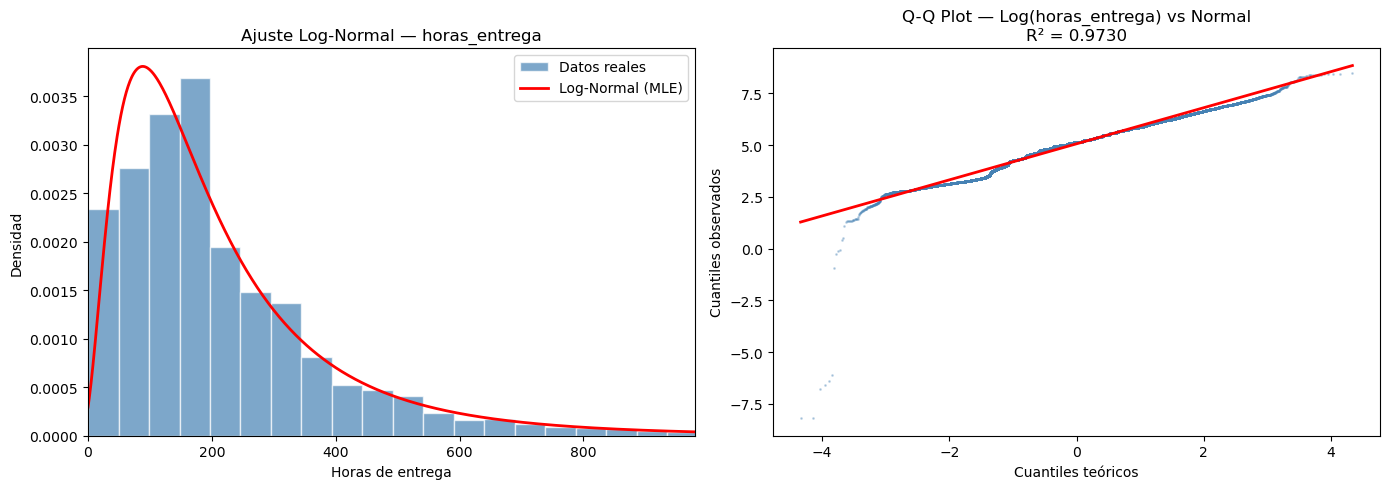

Parámetros Log-Normal (MLE):
  μ (media del log): 5.2308
  σ (std del log):   0.7341

Media estimada:   224.01 horas
Mediana estimada: 166.21 horas
Percentil 95:     604.57 horas


In [130]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

entrega = master_clean["horas_entrega"].values

# Ajuste Log-Normal
params_ln = stats.lognorm.fit(entrega)

x = np.linspace(entrega.min(), np.percentile(entrega, 99), 1000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfica 1: histograma + ajuste ---
axes[0].hist(entrega, bins=100, density=True, color="steelblue",
             edgecolor="white", alpha=0.7, label="Datos reales")
axes[0].plot(x, stats.lognorm.pdf(x, *params_ln),
             color="red", linewidth=2, label="Log-Normal (MLE)")
axes[0].set_xlim(0, np.percentile(entrega, 99))
axes[0].set_title("Ajuste Log-Normal — horas_entrega")
axes[0].set_xlabel("Horas de entrega")
axes[0].set_ylabel("Densidad")
axes[0].legend()

# --- Gráfica 2: Q-Q plot ---
(osm, osr), (slope, intercept, r) = stats.probplot(
    np.log(entrega), dist="norm"
)
axes[1].scatter(osm, osr, alpha=0.3, s=1, color="steelblue")
axes[1].plot(osm, slope * np.array(osm) + intercept,
             color="red", linewidth=2)
axes[1].set_title(f"Q-Q Plot — Log(horas_entrega) vs Normal\nR² = {r**2:.4f}")
axes[1].set_xlabel("Cuantiles teóricos")
axes[1].set_ylabel("Cuantiles observados")

plt.tight_layout()
plt.show()

# Parámetros interpretables
sigma, loc, scale = params_ln
mu = np.log(scale)
print(f"Parámetros Log-Normal (MLE):")
print(f"  μ (media del log): {mu:.4f}")
print(f"  σ (std del log):   {sigma:.4f}")
print(f"\nMedia estimada:   {stats.lognorm.mean(*params_ln):.2f} horas")
print(f"Mediana estimada: {stats.lognorm.median(*params_ln):.2f} horas")
print(f"Percentil 95:     {stats.lognorm.ppf(0.95, *params_ln):.2f} horas")

Observamos que la curva log-normal captura bien de manera aproximada la distribución de las horas de entrega (con R2 de 0.9730). Podemos decir que los tiempos de entrega siguen un proceso multiplicativo, es decir, un retraso en una etapa se amplifica en las siguientes.

El Q-Q plot (que nos permite saber si una distribución teórica se parece a una real si los puntos siguen una línea recta). La cola separada de la línea roja a la izquierda son las observaciones en las que las entregas son más rápidas de lo que log-normal pudo predecir, entregas probablemente hechas en la misma ciudad, y al contrario, las de la derecha son las que las entregas son más lentas de lo que log-normal pudo predecir.

A partir de la mediana, sabemos que la mitad de los pedidos tardan menos de 7 días en llegar, lo que es más confiable que la media porque la distribución es asimétrica, y el percentil 95 nos sugiere que el 5% de los pedidos tardan más de 604.57 horas en llegar, lo que serían aprox. 25 días.

Para interpretar la desviación en escala logarítmica, calculamos el rango de desviación con respecto a la media, con el percentil usado en regla empírica de la distribución normal:

In [131]:
mu    = 5.2308
sigma = 0.7341

print("Intervalo 95% (μ ± 2σ):")
print(f"  {np.exp(mu - 2*sigma):.0f} — {np.exp(mu + 2*sigma):.0f} horas")
print(f"  {np.exp(mu - 2*sigma)/24:.1f} — {np.exp(mu + 2*sigma)/24:.1f} días")

Intervalo 95% (μ ± 2σ):
  43 — 812 horas
  1.8 — 33.8 días


El 95% de los tiempos de entrega están entre 43 y 812 horas, es decir, entre 1.8 y 33.8 días. Este rango puede ser comunicado por Olist al cliente al momento de la compra como: "Tu pedido tardará no más de un mes en llegar", ya que comunicar solo el valor más optimista sería engañoso, en cambio, prometer el límite superior podría aumentar la confianza del cliente cuando el pedido llegue antes.

In [132]:
regiones = {
    "Norte"      : ["AM","RR","AP","PA","TO","RO","AC"],
    "Nordeste"   : ["MA","PI","CE","RN","PB","PE","AL","SE","BA"],
    "Centro-Oeste": ["MT","MS","GO","DF"],
    "Sudeste"    : ["SP","RJ","MG","ES"],
    "Sur"        : ["PR","SC","RS"]
}

estado_a_region = {est: reg for reg, estados in regiones.items() for est in estados}

master_clean["region"] = master_clean["customer_state"].map(estado_a_region)

master_clean["grupo"] = master_clean["customer_state"].apply(
    lambda x: "São Paulo" if x == "SP" else estado_a_region.get(x, "Otro")
)

print(master_clean["grupo"].value_counts())

grupo
São Paulo       40234
Sudeste         25431
Sur             13727
Nordeste         8946
Centro-Oeste     5421
Norte            1774
Name: count, dtype: int64


In [133]:
grupos = ["São Paulo", "Sudeste", "Sur", "Nordeste", "Centro-Oeste", "Norte"]
colores = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]

resultados_region = []

for grupo in grupos:
    datos = master_clean[master_clean["grupo"] == grupo]["horas_entrega"].values
    params = stats.lognorm.fit(datos)
    sigma, loc, scale = params
    mu = np.log(scale)
    
    mediana  = stats.lognorm.median(*params)
    media    = stats.lognorm.mean(*params)
    p95      = stats.lognorm.ppf(0.95, *params)
    lim_inf  = np.exp(mu - 2*sigma)
    lim_sup  = np.exp(mu + 2*sigma)

    resultados_region.append({
        "Grupo"         : grupo,
        "n"             : len(datos),
        "μ"             : round(mu, 4),
        "σ"             : round(sigma, 4),
        "Mediana (hrs)" : round(mediana, 1),
        "Mediana (días)": round(mediana/24, 1),
        "P95 (días)"    : round(p95/24, 1),
        "IC 95% (días)" : f"{lim_inf/24:.1f} — {lim_sup/24:.1f}"
    })

df_region = pd.DataFrame(resultados_region)
print(df_region.to_string(index=False))

       Grupo     n      μ      σ  Mediana (hrs)  Mediana (días)  P95 (días) IC 95% (días)
   São Paulo 40234 4.5824 0.8286           95.9             4.0        15.8    0.8 — 21.4
     Sudeste 25431 5.4064 0.6225          202.9             8.5        25.0    2.7 — 32.2
         Sur 13727 5.5569 0.5280          218.4             9.1        24.0    3.8 — 31.0
    Nordeste  8946 5.9615 0.4943          343.9            14.3        34.6    6.0 — 43.5
Centro-Oeste  5421 5.7415 0.4432          251.5            10.5        24.4    5.3 — 31.5
       Norte  1774 6.0368 0.5074          400.6            16.7        39.4    6.3 — 48.1


La mediana de horas de entrega de la región Norte es 4 veces el valor de la de Sao Paulo, que es la mediana de horas de entrega más baja entre todas las regiones, y en el Nordeste es casi 3 veces la de Sao Paulo. Esto justifica tomar las siguientes acciones: prometer fechas de entrega específicas por región, priorizar centros de distribución en el Nordeste y Norte, y segmentar la estrategia de satisfacción del cliente por región.

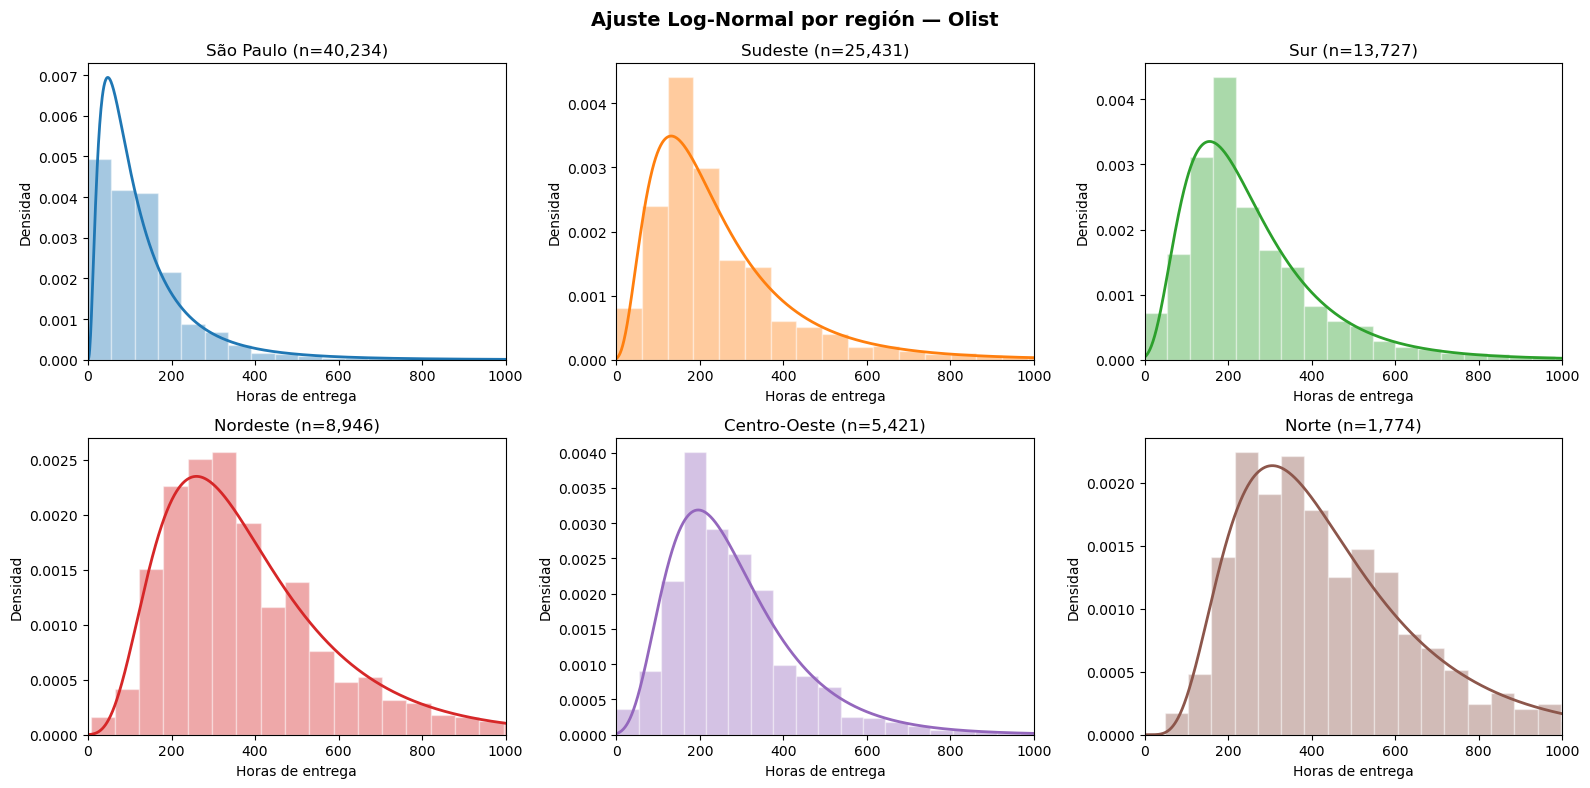

In [134]:
# Visualización — PDFs por región
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

x = np.linspace(1, 1000, 1000)

for i, (grupo, color) in enumerate(zip(grupos, colores)):
    datos  = master_clean[master_clean["grupo"] == grupo]["horas_entrega"].values
    params = stats.lognorm.fit(datos)
    
    axes[i].hist(datos, bins=80, density=True,
                 color=color, alpha=0.4, edgecolor="white")
    axes[i].plot(x, stats.lognorm.pdf(x, *params),
                 color=color, linewidth=2)
    axes[i].set_xlim(0, 1000)
    axes[i].set_title(f"{grupo} (n={len(datos):,})")
    axes[i].set_xlabel("Horas de entrega")
    axes[i].set_ylabel("Densidad")

plt.suptitle("Ajuste Log-Normal por región — Olist", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Puede verse como las distribución de las regiones Norte, Nordeste y Centro-Oeste tienden a tener mayor densidad a la derecha, donde se encuentran los tiempos de entrega más altos, siendo Sudeste y Sur un punto medio entre estas y Sao Paulo que está en el otro extremo del espectro de rapidez, siendo la región con las entregas más rápidas.

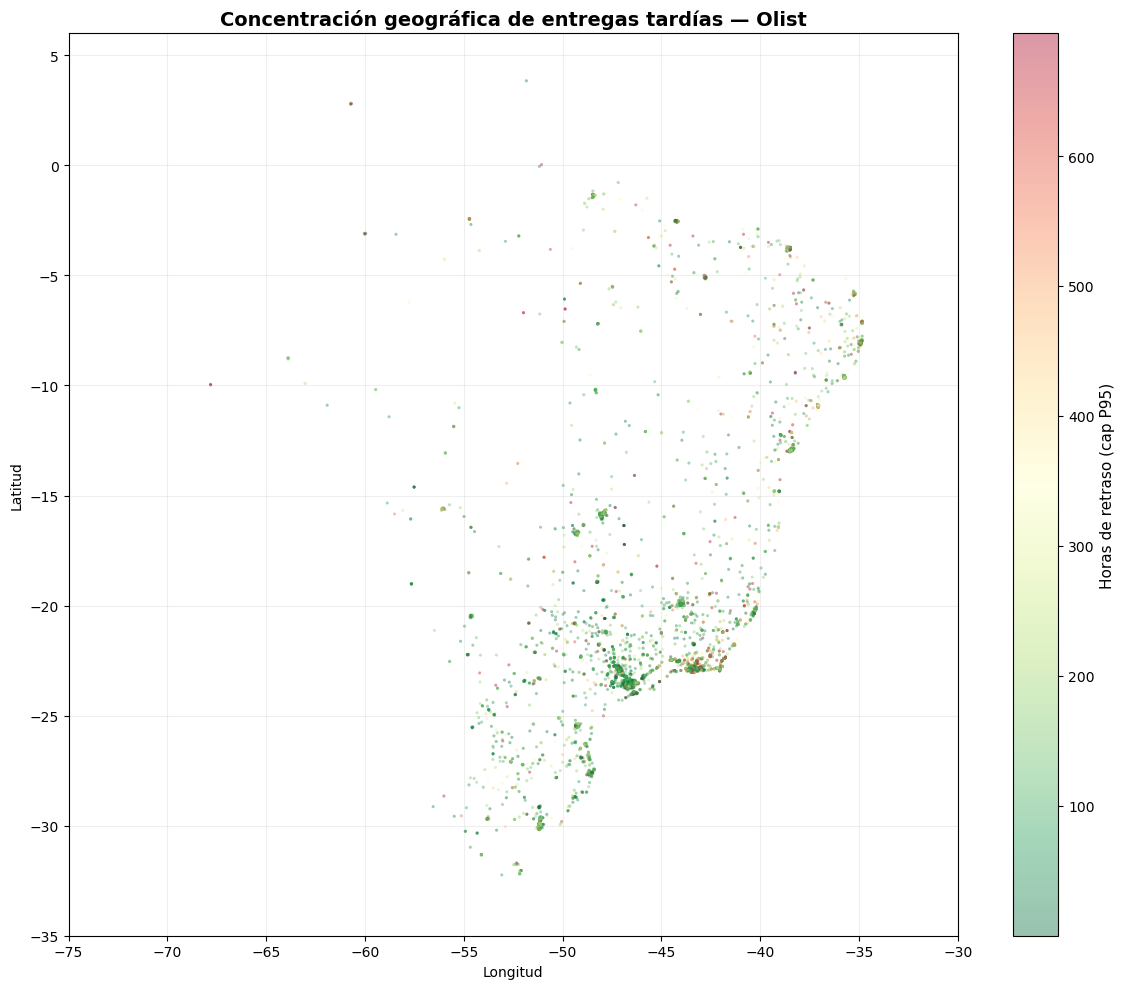

Órdenes tardías graficadas: 7,631
Cap de retraso (P95):       694.4 horas (28.9 días)


In [135]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Solo órdenes tardías con coordenadas
mapa_data = master_clean[
    (master_clean["horas_retraso"] > 0) &
    (master_clean["lat"].notna()) &
    (master_clean["lng"].notna())
].copy()

# Limitar horas_retraso al percentil 95 para que el color no lo domine un outlier
p95_retraso = mapa_data["horas_retraso"].quantile(0.95)
mapa_data["retraso_plot"] = mapa_data["horas_retraso"].clip(upper=p95_retraso)

fig, ax = plt.subplots(figsize=(12, 10))

scatter = ax.scatter(
    mapa_data["lng"],
    mapa_data["lat"],
    c=mapa_data["retraso_plot"],
    cmap="RdYlGn_r",      # verde = poco retraso, rojo = mucho retraso
    alpha=0.4,
    s=5,
    linewidths=0
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Horas de retraso (cap P95)", fontsize=11)

ax.set_title("Concentración geográfica de entregas tardías — Olist",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")

# Líneas de referencia para Brasil
ax.set_xlim(-75, -30)
ax.set_ylim(-35, 6)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(f"Órdenes tardías graficadas: {len(mapa_data):,}")
print(f"Cap de retraso (P95):       {p95_retraso:.1f} horas ({p95_retraso/24:.1f} días)")

Puede observarse como la región sudeste presenta mucho volumen de entregas tardías pero la mayoría son puntos verdes, es decir, retrasos cortos. Las zonas norte y nordeste, a pesar de su bajo volumen, muestran retrasos más largos alrededor de la costa. No todo el nordeste tiene problemas de retrasos, sino zonas costeras específicas. Para Olist tendría impacto aplicar una intervención en esa zona en lugar de una generalizada en toda la región.

¿Existen perfiles de comprador diferenciados según su comportamiento de compra (valor del pedido, frecuencia, método de pago, región geográfica)?

In [136]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# Variables para K-Means
features_kmeans = [
    "precio_total",
    "flete_total",
    "freight_ratio",
    "num_items",
    "horas_entrega",
    "horas_retraso"
]

# Eliminar nulos en esas columnas
kmeans_data = master_clean[features_kmeans].dropna().copy()

# Escalar — K-Means es sensible a la escala
scaler = StandardScaler()
kmeans_scaled = scaler.fit_transform(kmeans_data)

print(f"Observaciones para K-Means: {len(kmeans_data):,}")
print(f"Variables: {features_kmeans}")

Observaciones para K-Means: 95,199
Variables: ['precio_total', 'flete_total', 'freight_ratio', 'num_items', 'horas_entrega', 'horas_retraso']


k=2 — inercia: 482,638 | silhouette: 0.5562
k=3 — inercia: 408,347 | silhouette: 0.3970
k=4 — inercia: 349,837 | silhouette: 0.2660
k=5 — inercia: 308,809 | silhouette: 0.2824
k=6 — inercia: 283,214 | silhouette: 0.2971
k=7 — inercia: 264,019 | silhouette: 0.2216
k=8 — inercia: 245,479 | silhouette: 0.2282
k=9 — inercia: 229,072 | silhouette: 0.2362
k=10 — inercia: 214,020 | silhouette: 0.2361


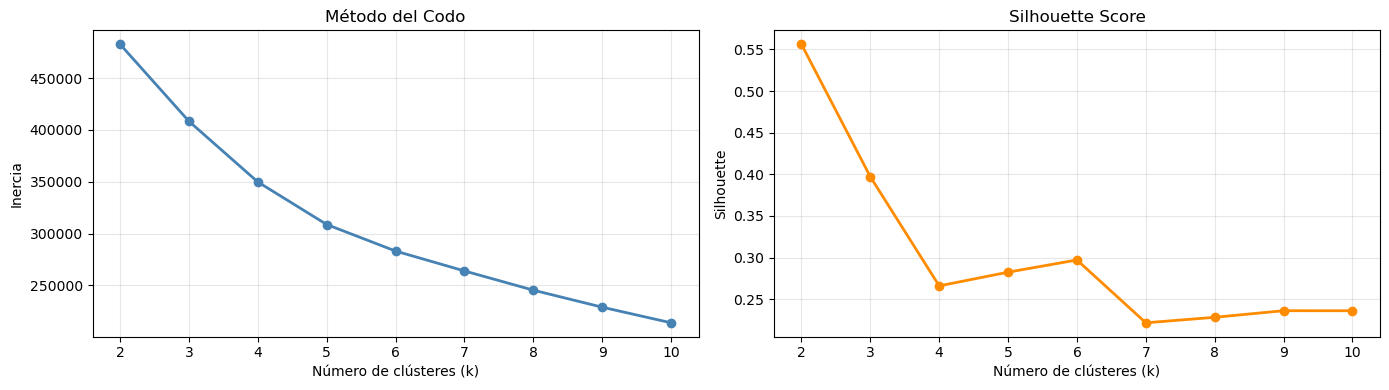

In [137]:
# Método del codo + Silhouette
inercias    = []
silhouettes = []
K           = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(kmeans_scaled)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(kmeans_scaled, km.labels_, sample_size=10000))
    print(f"k={k} — inercia: {km.inertia_:,.0f} | silhouette: {silhouettes[-1]:.4f}")

# Gráficas
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(K, inercias, "o-", color="steelblue", linewidth=2)
axes[0].set_title("Método del Codo")
axes[0].set_xlabel("Número de clústeres (k)")
axes[0].set_ylabel("Inercia")
axes[0].grid(alpha=0.3)

axes[1].plot(K, silhouettes, "o-", color="darkorange", linewidth=2)
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Número de clústeres (k)")
axes[1].set_ylabel("Silhouette")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

A partir del método del codo no es exactamente claro cuántos son los clústeres efectivos, sin embargo, el score de silueta favorece 2 clústeres. Como sólo 2 clústeres no tienen tanto material analítico, probaremos ajustar 2 y 3 clústeres.

In [138]:
# Ajustar k=2 y k=3
for k in [2, 3]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(kmeans_scaled)
    
    kmeans_data[f"cluster_k{k}"] = labels
    
    print(f"\n{'='*50}")
    print(f"K = {k}")
    print(f"{'='*50}")
    print(kmeans_data.groupby(f"cluster_k{k}")[features_kmeans].mean().round(2))
    print(f"\nTamaño de clústeres:")
    print(kmeans_data[f"cluster_k{k}"].value_counts().sort_index())


K = 2
            precio_total  flete_total  freight_ratio  num_items  \
cluster_k2                                                        
0                 555.05        71.83           0.19       2.27   
1                 108.50        19.51           0.21       1.06   

            horas_entrega  horas_retraso  
cluster_k2                                
0                  237.28        -305.39  
1                  221.90        -266.60  

Tamaño de clústeres:
cluster_k2
0     6051
1    89148
Name: count, dtype: int64

K = 3
            precio_total  flete_total  freight_ratio  num_items  \
cluster_k3                                                        
0                 110.08        19.10           0.21       1.07   
1                 120.84        24.99           0.24       1.06   
2                 573.22        74.94           0.19       2.38   

            horas_entrega  horas_retraso  
cluster_k3                                
0                  169.12        -314.58  

Vemos como 3 clústeres delimitan tres tipos de clientes:

Cluster 0: es el grupo mayoritario, y podemos llamarlo el comportamiento normal en Olist. Son órdenes estándar con precio más bajo de 110 BRL, costo de flete de 19 BRL, que representa un 21% de costo de la compra, con 1 ítem, con entregas de 7 días y retraso muy negativo, es decir, llegan mucho antes de lo prometido.

Cluster 1: son las órdenes problemáticas, tienen un costo relativamente bajo, sin embargo son las que más pagan en flete con un 24%, y son las únicas órdenes con retraso (horas_retraso positivo), además de demorar 3,7 veces más que el cluster 0.

Cluster 2: son las órdenes de alto valor, que pagan un flete alto pero que representa el 19% de la compra (el más bajo de los 3 clústeres), además de tener la mayor cantidad de ítems, y ser las órdenes que más rápido se entregan frente a lo que se promete, con un retraso de -325, a pesar de demorarse más que en el cluster 0.

¿Cuál es la probabilidad real de recibir una calificación baja (≤ 2) dada una entrega tardía, y cómo se actualiza esa creencia cuando además el producto es de una categoría con alto costo de flete?

Para responder esto, usamos inferencia bayesiana.

Nuestro θ es la probabilidad de recibir una calificación baja dado que la órden es tardía. Nuestra creencia inicial es una prior no informativa Beta(1,1) porque no se cuenta con información externa sobre la tasa de insatisfacción de Olist previo al análisis, además, es útil que la distribución Beta viva entre 0 y 1 porque estamos buscando una probabilidad para θ


Tardías:
  Posterior:  Beta(4129, 3504)
  Media:      0.5409
  IC 95%:     [0.5298, 0.5521]

Puntuales:
  Posterior:  Beta(8106, 79798)
  Media:      0.0922
  IC 95%:     [0.0903, 0.0941]


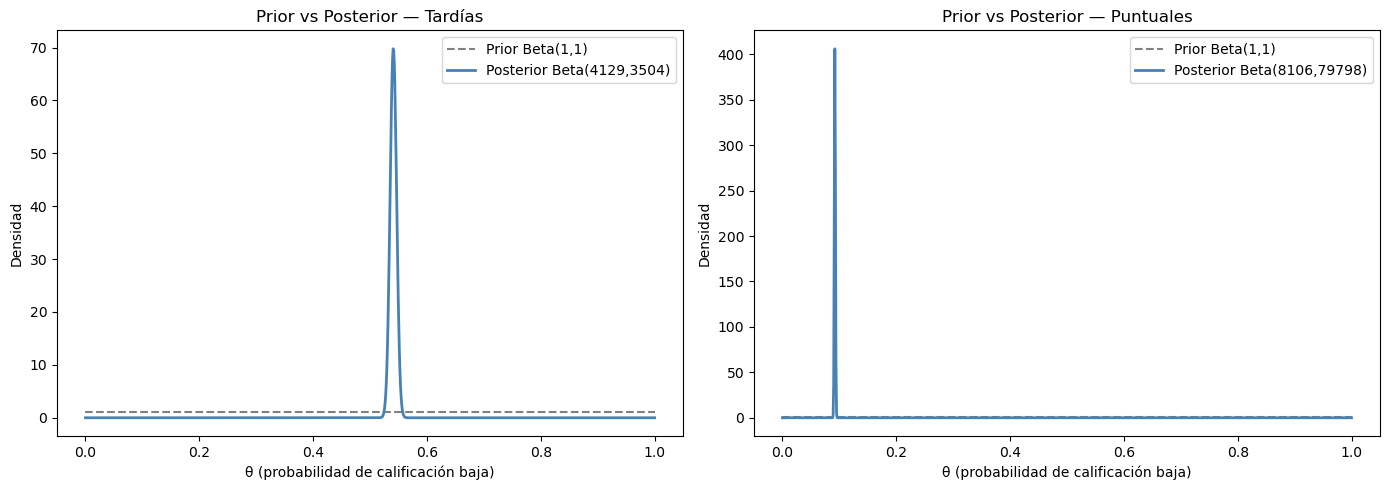

In [139]:
from scipy import stats

# ── Priors no informativas ────────────────────────────────────────────────────
alpha_prior = 1
beta_prior  = 1

# ── Datos desde master_clean ──────────────────────────────────────────────────
tardias   = master_clean[master_clean["entrega_tardía"]]
puntuales = master_clean[~master_clean["entrega_tardía"]]

bajas_t    = tardias["calificacion_baja"].sum()
no_bajas_t = len(tardias) - bajas_t

bajas_p    = puntuales["calificacion_baja"].sum()
no_bajas_p = len(puntuales) - bajas_p

# ── Posterior Beta conjugada ──────────────────────────────────────────────────
alpha_post_t = alpha_prior + bajas_t
beta_post_t  = beta_prior  + no_bajas_t

alpha_post_p = alpha_prior + bajas_p
beta_post_p  = beta_prior  + no_bajas_p

# ── Métricas ──────────────────────────────────────────────────────────────────
for nombre, ap, bp in [("Tardías",   alpha_post_t, beta_post_t),
                        ("Puntuales", alpha_post_p, beta_post_p)]:
    media           = ap / (ap + bp)
    ic_low, ic_high = stats.beta.ppf([0.025, 0.975], ap, bp)
    print(f"\n{nombre}:")
    print(f"  Posterior:  Beta({ap}, {bp})")
    print(f"  Media:      {media:.4f}")
    print(f"  IC 95%:     [{ic_low:.4f}, {ic_high:.4f}]")

# ── Gráfica prior vs posterior ────────────────────────────────────────────────
x = np.linspace(0, 1, 1000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (nombre, ap, bp) in zip(axes, [
    ("Tardías",   alpha_post_t, beta_post_t),
    ("Puntuales", alpha_post_p, beta_post_p)
]):
    ax.plot(x, stats.beta.pdf(x, alpha_prior, beta_prior),
            color="gray", linewidth=1.5, linestyle="--", label="Prior Beta(1,1)")
    ax.plot(x, stats.beta.pdf(x, ap, bp),
            color="steelblue", linewidth=2, label=f"Posterior Beta({ap},{bp})")
    ax.set_title(f"Prior vs Posterior — {nombre}")
    ax.set_xlabel("θ (probabilidad de calificación baja)")
    ax.set_ylabel("Densidad")
    ax.legend()

plt.tight_layout()
plt.show()

Hay un 95% de probabilidad de que la probabilidad de recibir una mala calificación dado que una entrega es tardía esté entre 52.98% y 55.21%, mientras que con la misma confianza, la probabilidad se mantiene entre 9.03% y 9.41% cuando la entrega es puntual. Ahora queremos determinar si esto cambia cuando el costo de flete es alto y además la entrega es tardía.

In [140]:
# Cargar traducción
traduccion = pd.read_csv("product_category_name_translation.csv")

# Construir items_con_cat desde cero con traducción incluida
items_con_cat = (
    items_clean
    .merge(products_clean[["product_id", "product_category_name"]],
           on="product_id", how="left")
    .merge(traduccion, on="product_category_name", how="left")
)

# Categoría dominante por orden en inglés
cat_por_orden = (
    items_con_cat.groupby("order_id")["product_category_name_english"]
    .agg(lambda x: x.mode()[0] if not x.mode().empty else "sin_categoria")
    .reset_index()
    .rename(columns={"product_category_name_english": "categoria_producto"})
)

# Eliminar columna anterior si ya existe y agregar la nueva
if "categoria_producto" in master_clean.columns:
    master_clean = master_clean.drop(columns=["categoria_producto"])

master_clean = master_clean.merge(cat_por_orden, on="order_id", how="left")

# Flete promedio por categoría en inglés
flete_por_cat = (
    items_con_cat.groupby("product_category_name_english")["freight_value"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"product_category_name_english": "product_category_name"})
)

print("Top 10 categorías con mayor flete promedio:")
print(flete_por_cat.head(10).to_string(index=False))

Top 10 categorías con mayor flete promedio:
                  product_category_name  freight_value
                              computers      48.454680
                      home_appliances_2      44.538571
      furniture_mattress_and_upholstery      42.906842
kitchen_dining_laundry_garden_furniture      42.702598
                      furniture_bedroom      42.497523
                       office_furniture      40.575118
  small_appliances_home_oven_and_coffee      36.156053
                  furniture_living_room      35.722008
                 signaling_and_security      32.702613
         industry_commerce_and_business      29.420448


Las categorías de producto con flete más alto son electrónicos, electrodomésticos y muebles para el hogar.

In [141]:
master_clean["calificacion_baja"] = master_clean["review_score"] <= 2

# Verificación
print(master_clean["calificacion_baja"].value_counts())
print(master_clean["calificacion_baja"].dtype)

calificacion_baja
False    83300
True     12233
Name: count, dtype: int64
bool


In [142]:
# Umbral: categorías con flete promedio > percentil 75
umbral_flete = flete_por_cat["freight_value"].quantile(0.75)
print(f"Umbral flete alto (percentil 75): {umbral_flete:.2f} BRL")

cats_alto_flete = flete_por_cat[
    flete_por_cat["freight_value"] >= umbral_flete
]["product_category_name"].tolist()

print(f"Categorías con alto flete: {len(cats_alto_flete)}")

# Crear variable en master_clean
master_clean["alto_flete_cat"] = master_clean["categoria_producto"].isin(cats_alto_flete)

# ── Tres grupos de análisis ───────────────────────────────────────────────────
# 1. Tardía + alto flete
# 2. Tardía + bajo flete
# 3. Puntual (referencia)

grupo1 = master_clean[master_clean["entrega_tardía"] & master_clean["alto_flete_cat"]]
grupo2 = master_clean[master_clean["entrega_tardía"] & ~master_clean["alto_flete_cat"]]
grupo3 = master_clean[~master_clean["entrega_tardía"]]

for nombre, df in [("Tardía + alto flete", grupo1),
                   ("Tardía + bajo flete", grupo2),
                   ("Puntual (referencia)", grupo3)]:
    bajas = df["calificacion_baja"].sum()
    n     = len(df)
    print(f"\n{nombre}: {bajas} bajas de {n} → tasa = {bajas/n:.4f}")

Umbral flete alto (percentil 75): 22.81 BRL
Categorías con alto flete: 18

Tardía + alto flete: 379 bajas de 703 → tasa = 0.5391

Tardía + bajo flete: 3749 bajas de 6928 → tasa = 0.5411

Puntual (referencia): 8105 bajas de 87902 → tasa = 0.0922


Definimos el percentil 75 de la distribución de costo de flete como valor alto, que terminó siendo 22.62 BRL. Así, 713 órdenes entran en la categoría de orden tardía y con alto flete, de las cuales el 54.14% terminó teniendo una calificación baja. Hubo también 6819 órdenes tardías con bajo flete, de las cuales el 54.09% tienen una calificación baja, mientras que las ordenes puntuales se mantienen en 9% de calificaciones bajas.

               Grupo     n  θ media           IC 95%
 Tardía + alto flete   703   0.5390 [0.5021, 0.5757]
 Tardía + bajo flete  6928   0.5411 [0.5294, 0.5528]
Puntual (referencia) 87902   0.0922 [0.0903, 0.0941]


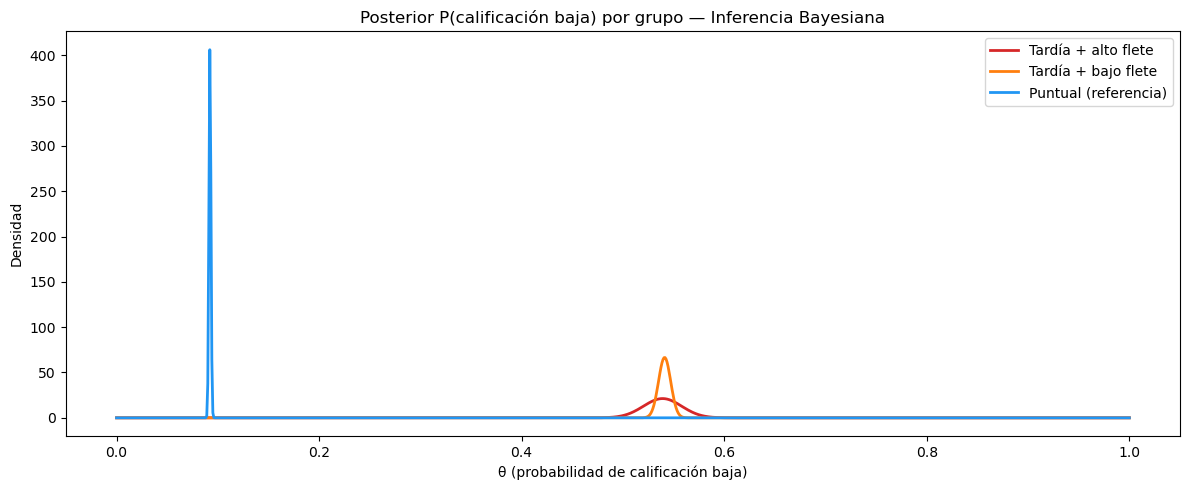

In [143]:
# ── Posteriors para los tres grupos ──────────────────────────────────────────
alpha_prior = 1
beta_prior  = 1

grupos_bayes = {
    "Tardía + alto flete" : grupo1,
    "Tardía + bajo flete" : grupo2,
    "Puntual (referencia)": grupo3
}

resultados_bayes = []

for nombre, df in grupos_bayes.items():
    bajas    = df["calificacion_baja"].sum()
    no_bajas = len(df) - bajas
    ap       = alpha_prior + bajas
    bp       = beta_prior  + no_bajas
    media    = ap / (ap + bp)
    ic_low, ic_high = stats.beta.ppf([0.025, 0.975], ap, bp)
    resultados_bayes.append({
        "Grupo"  : nombre,
        "n"      : len(df),
        "θ media": round(media, 4),
        "IC 95%" : f"[{ic_low:.4f}, {ic_high:.4f}]"
    })

import pandas as pd
print(pd.DataFrame(resultados_bayes).to_string(index=False))

# ── Gráfica ───────────────────────────────────────────────────────────────────
x      = np.linspace(0, 1, 1000)
colores = ["#d62728", "#ff7f0e", "#2196F3"]

fig, ax = plt.subplots(figsize=(12, 5))

for (nombre, df), color in zip(grupos_bayes.items(), colores):
    bajas    = df["calificacion_baja"].sum()
    no_bajas = len(df) - bajas
    ap       = alpha_prior + bajas
    bp       = beta_prior  + no_bajas
    ax.plot(x, stats.beta.pdf(x, ap, bp),
            color=color, linewidth=2, label=nombre)

ax.set_title("Posterior P(calificación baja) por grupo — Inferencia Bayesiana")
ax.set_xlabel("θ (probabilidad de calificación baja)")
ax.set_ylabel("Densidad")
ax.legend()
plt.tight_layout()
plt.show()

Los resultados muestran que el costo de flete no actualiza la creencia de insatisfacción, se mantiene igualmente alrededor de 54% la probabilidad de una calificación baja dada una orden tardía, tenga alto costo de flete o no, lo que sugiere que la insatisfacción del cliente ya está determinada cuando el pedido llega tarde, ya que el costo de envío deja de importar. La recomendación para Olist es invertir en entregas más rápidas, en lugar de intentar bajar los costos de envío si lo que quiere es mejorar la satisfacción del cliente.

¿Cuál es la distribución esperada del costo total de flete mensual bajo distintos escenarios de demanda, y cuál es el percentil 95 de ese costo? ¿Cuántos días adicionales de retraso puede esperar Olist en el peor 5% de los escenarios si la demanda crece un 20%?

In [144]:
# Excluir meses incompletos
meses_incompletos = ["2016-09", "2016-12", "2018-09", "2018-10"]

master_clean["year_month"] = master_clean[
    "order_purchase_timestamp"
].dt.to_period("M").astype(str)

master_valido = master_clean[~master_clean["year_month"].isin(meses_incompletos)]

# ── Pregunta 1: flete mensual ─────────────────────────────────────────────────
flete_mensual = (
    master_valido.groupby("year_month")["flete_total"]
    .sum()
    .reset_index()
    .rename(columns={"flete_total": "flete_mes"})
)

# ── Pregunta 2: órdenes por mes y horas_entrega ───────────────────────────────
ordenes_mensual = (
    master_valido.groupby("year_month")["order_id"]
    .count()
    .reset_index()
    .rename(columns={"order_id": "ordenes_mes"})
)

print("Flete mensual:")
print(f"  Media:  {flete_mensual['flete_mes'].mean():,.0f} BRL")
print(f"  Std:    {flete_mensual['flete_mes'].std():,.0f} BRL")
print(f"  Min:    {flete_mensual['flete_mes'].min():,.0f} BRL")
print(f"  Max:    {flete_mensual['flete_mes'].max():,.0f} BRL")
print(f"  Meses:  {len(flete_mensual)}")

print("\nÓrdenes mensuales:")
print(f"  Media:  {ordenes_mensual['ordenes_mes'].mean():,.0f}")
print(f"  Std:    {ordenes_mensual['ordenes_mes'].std():,.0f}")
print(f"  Min:    {ordenes_mensual['ordenes_mes'].min():,.0f}")
print(f"  Max:    {ordenes_mensual['ordenes_mes'].max():,.0f}")

Flete mensual:
  Media:  103,517 BRL
  Std:    51,652 BRL
  Min:    6,037 BRL
  Max:    165,411 BRL
  Meses:  21

Órdenes mensuales:
  Media:  4,549
  Std:    2,182
  Min:    262
  Max:    7,216


In [145]:
import numpy as np

data = master_clean["flete_total"].values

print("NaN:", np.isnan(data).sum())
print("Inf:", np.isinf(data).sum())
print("<= 0:", (data <= 0).sum())

NaN: 334
Inf: 0
<= 0: 0


Vemos que hay 334 nulos en flete_total, que podrían ser de envíos gratis, sin embargo, para mantener las simulaciones de Monte Carlo limpias, se excluyen solo para esta técnica.

Flete promedio por orden:        22.84 BRL
Órdenes promedio por mes:        4549
Parámetros Log-Normal — μ: 5.2308 | σ: 0.7341

=== PREGUNTA 1: Costo flete mensual ===
Media simulada:     101,845 BRL
Percentil 5:        13,618 BRL  (escenario optimista)
Mediana:            77,301 BRL
Percentil 95 (VaR): 269,148 BRL  (escenario de riesgo)

=== PREGUNTA 2: Retraso con demanda +20% ===
P95 horas entrega (base):    605.1 hrs (25.2 días)
P95 horas entrega (+20%):    726.1 hrs (30.3 días)
Horas adicionales (peor 5%): 121.0 hrs (5.0 días)


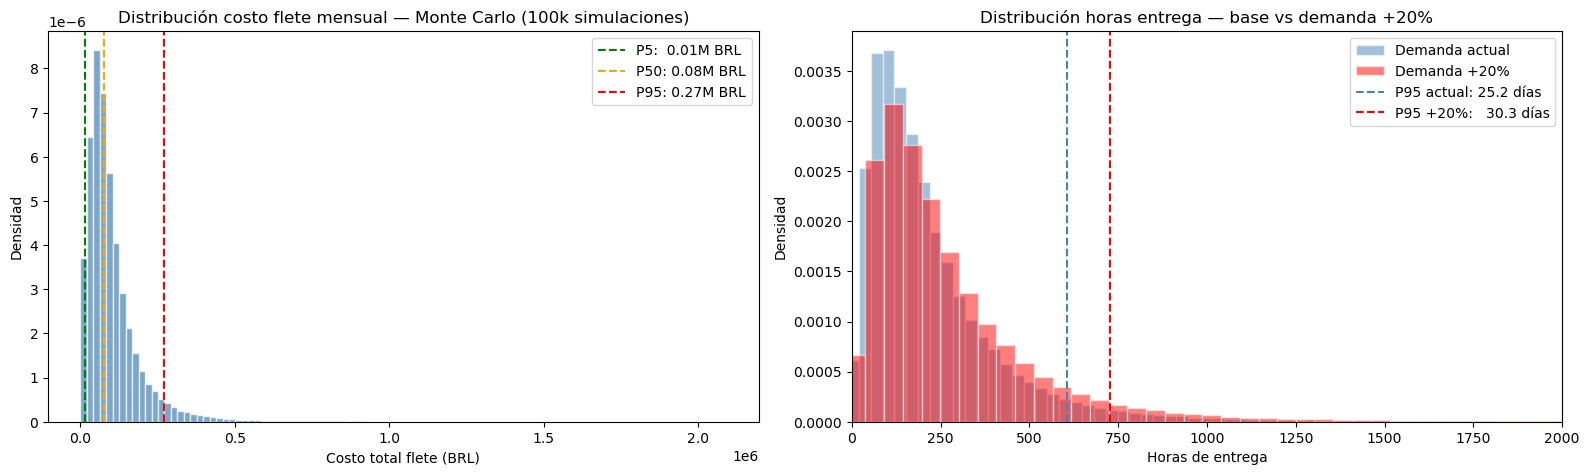

In [146]:
np.random.seed(42)
N_SIM = 100000

# ── Parámetros empíricos ──────────────────────────────────────────────────────
media_flete_orden = master_clean["flete_total"].mean()
std_flete_orden   = master_clean["flete_total"].std()
media_ordenes_mes = ordenes_mensual["ordenes_mes"].mean()
std_ordenes_mes   = ordenes_mensual["ordenes_mes"].std()

# Parámetros Log-Normal globales desde horas_entrega
entrega_valida   = master_clean[master_clean["horas_entrega"] > 0]["horas_entrega"]
params_ln_global = stats.lognorm.fit(entrega_valida.values)
sigma_g, loc_g, scale_g = params_ln_global
mu_g = np.log(scale_g)

print(f"Flete promedio por orden:        {media_flete_orden:.2f} BRL")
print(f"Órdenes promedio por mes:        {media_ordenes_mes:.0f}")
print(f"Parámetros Log-Normal — μ: {mu_g:.4f} | σ: {sigma_g:.4f}")

# ════════════════════════════════════════════════════════════════════════════════
# PREGUNTA 1 — Costo total de flete mensual
# ════════════════════════════════════════════════════════════════════════════════
ordenes_sim = np.random.normal(media_ordenes_mes, std_ordenes_mes, N_SIM).astype(int)
ordenes_sim = np.clip(ordenes_sim, 1, None)

# ── Separar datos ─────────────────────────────────────────────────────────────
flete_data = master_clean["flete_total"].values

# Probabilidad de envío gratis (NaN)
p_gratis = np.mean(np.isnan(flete_data))

# Datos válidos (solo positivos)
flete_clean = flete_data[np.isfinite(flete_data)]

# Ajuste lognormal SOLO con datos válidos
params_flete = stats.lognorm.fit(flete_clean)

# ── Simulación ────────────────────────────────────────────────────────────────
gratis_sim = np.random.rand(N_SIM) < p_gratis

flete_sim = np.where(
    gratis_sim,
    0,
    stats.lognorm.rvs(*params_flete, size=N_SIM)
)

costo_mensual_sim = ordenes_sim * flete_sim

p5   = np.percentile(costo_mensual_sim, 5)
p50  = np.percentile(costo_mensual_sim, 50)
p95  = np.percentile(costo_mensual_sim, 95)

print(f"\n=== PREGUNTA 1: Costo flete mensual ===")
print(f"Media simulada:     {costo_mensual_sim.mean():,.0f} BRL")
print(f"Percentil 5:        {p5:,.0f} BRL  (escenario optimista)")
print(f"Mediana:            {p50:,.0f} BRL")
print(f"Percentil 95 (VaR): {p95:,.0f} BRL  (escenario de riesgo)")

# ════════════════════════════════════════════════════════════════════════════════
# PREGUNTA 2 — Horas de entrega si demanda crece 20%
# ════════════════════════════════════════════════════════════════════════════════
horas_base = stats.lognorm.rvs(*params_ln_global, size=N_SIM)
horas_20   = stats.lognorm.rvs(sigma_g, loc_g, scale_g * 1.20, size=N_SIM)

p95_base   = np.percentile(horas_base, 95)
p95_20     = np.percentile(horas_20,   95)
diferencia = p95_20 - p95_base

print(f"\n=== PREGUNTA 2: Retraso con demanda +20% ===")
print(f"P95 horas entrega (base):    {p95_base:.1f} hrs ({p95_base/24:.1f} días)")
print(f"P95 horas entrega (+20%):    {p95_20:.1f} hrs ({p95_20/24:.1f} días)")
print(f"Horas adicionales (peor 5%): {diferencia:.1f} hrs ({diferencia/24:.1f} días)")

# ── Gráficas ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(costo_mensual_sim, bins=100, density=True,
             color="steelblue", edgecolor="white", alpha=0.7)
axes[0].axvline(p5,  color="green",  linestyle="--", linewidth=1.5, label=f"P5:  {p5/1e6:.2f}M BRL")
axes[0].axvline(p50, color="orange", linestyle="--", linewidth=1.5, label=f"P50: {p50/1e6:.2f}M BRL")
axes[0].axvline(p95, color="red",    linestyle="--", linewidth=1.5, label=f"P95: {p95/1e6:.2f}M BRL")
axes[0].set_title("Distribución costo flete mensual — Monte Carlo (100k simulaciones)")
axes[0].set_xlabel("Costo total flete (BRL)")
axes[0].set_ylabel("Densidad")
axes[0].legend()

axes[1].hist(horas_base, bins=100, density=True,
             color="steelblue", edgecolor="white", alpha=0.5, label="Demanda actual")
axes[1].hist(horas_20,   bins=100, density=True,
             color="red",       edgecolor="white", alpha=0.5, label="Demanda +20%")
axes[1].axvline(p95_base, color="steelblue", linestyle="--", linewidth=1.5,
                label=f"P95 actual: {p95_base/24:.1f} días")
axes[1].axvline(p95_20,   color="red",       linestyle="--", linewidth=1.5,
                label=f"P95 +20%:   {p95_20/24:.1f} días")
axes[1].set_xlim(0, 2000)
axes[1].set_title("Distribución horas entrega — base vs demanda +20%")
axes[1].set_xlabel("Horas de entrega")
axes[1].set_ylabel("Densidad")
axes[1].legend()

plt.tight_layout()
plt.show()

In [147]:
# Verificar consistencia
flete_mensual_real = flete_mensual["flete_mes"].mean()
flete_mensual_sim  = costo_mensual_sim.mean()

print(f"Media histórica (datos reales): {flete_mensual_real:,.0f} BRL")
print(f"Media simulada (Monte Carlo):   {flete_mensual_sim:,.0f} BRL")
print(f"Diferencia:                     {abs(flete_mensual_real - flete_mensual_sim):,.0f} BRL "
      f"({abs(flete_mensual_real - flete_mensual_sim)/flete_mensual_real*100:.1f}%)")

Media histórica (datos reales): 103,517 BRL
Media simulada (Monte Carlo):   101,845 BRL
Diferencia:                     1,672 BRL (1.6%)


El percentil 5 muestra que en el mejor 5% de los meses se gasta muy poco en flete (13618 BRL), el mes típico cuesta 77 mil BRL según la mediana.

El percentil 95 del costo mensual es aproximadamente 269,148 BRL, lo que indica que en el 5% de los escenarios más críticos, el costo puede superar este valor. Es decir, el presupuesto mensual de flete debería contemplar al menos 269K BRL como reserva de riesgo, no los 103K BRL del promedio histórico.

Además, si la demanda crece 20%, en los escenarios más críticos, Olist podría experimentar hasta 5 días adicionales de retraso. Son 5 días más de retraso si no se invierte en capacidad logística para los envíos, precisamente lo que ya genera insatisfacción en el cliente.

### 5. Evaluación

#### Evaluación técnica

1. MLE + AIC BIC: El mejor ajuste para las horas de entrega fue la distribución log-normal, con el menor AIC (1,211,474) y BIC (1,211,503) entre las candidatas. Se confirmó ajuste R2 = 0.973 con Q-Q plot en el rango central de la distribución, sin embargo, las colas indican casos extremos que son más frecuentes de lo que el modelo predice. Además, esta distribución se ajusta ta,bién por región, donde son todas log-normal, pero que difieren en parámetros, por lo que existe segmentación regional en cuanto a tiempos de entrega.

2. Clustering con KMEANS: Se eligieron 3 clusters para enriquecer la interpretabilidad, sin embargo, su score de silueta para k=3 fue 0.387, lo que podría considerarse relativamente bajo. Son necesarios estudios adicionales para evaluar la funcionalidad de ese score en datasets logísticos. A pesar de esto, los clusters son interpretables. Se distingue claramente un cluster problemático de n=10461 órdenes, que presenta 636 horas de entrega y es el único con horas de retraso positivas.

3. Inferencia bayesiana: Se usó una prior no informativa Beta(1,1) y 95533 observaciones. Los intervalos del 95% son estrechos con ±1.1 puntos porcentuales en entregas tardías y ±0.2 puntos porcentuales en entregas puntuales. Además, al evaluar si el costo de flete actualizaba la creencia sobre insatisfacción se encontró que no, por lo que hasta ahora, el retraso de las ordenes es lo que aumenta la probabilidad de calificaciones bajas.

4. Monte carlo: se hicieron 100 mil simulaciones, en donde la media simulada fue de 101845 BRL, que es consistente con la media histórica de 103517 BRL. El escenario de demanda +20% es una aproximación que no considera posibles mejoras en la eficiencia operativa de Olist.

#### Evaluación de negocio:
Recordando que la pregunta central era ¿qué factores logísticos determinan la satisfacción del cliente en Olist, qué segmentos geográficos concentran el mayor riesgo, y qué tan sostenible es esa operación bajo escenarios de crecimiento?

Con respecto a la predicibilidad se encontró que el tiempo de entrega sigue la distribución log-normal con R2=0.973 y el 95% de los envios llega entre 1.8 y 33.8 días, que es el rango que Olist puede comunicar ya que tiene respaldo estadístico.

La operación es parcialmente sostenible. El costo de flete en el peor 5% de los meses es de 268 mil BRL mensual, además de esto, un crecimiento del 20% de la demanda agregaría 5 días de retraso en el peor 5% de los envíos. Si se invierten esfuerzos en incrementar la demanda sin invertir en capacidad logística sería contraproducente para la satisfacción de los clientes de Olist.

Se encontró que el Norte y Nordeste concentran los tiempos de espera y de retraso de pedidos más largos, específicamente en la zona costera, además el cluster problemático contiene +10 mil ordenes con retrasos extremos independientemente de su valor comercial.

Además, aunado a todo esto, una entrega tardía multiplica por aproximadamente 6 veces la probabilidad de insatisfacción del cliente, sin tener nada que ver con el costo del flete.

### 6. Despliegue

Se presentan tres recomendaciones accionables para los ejecutivos de Olist:

- Necesitan diferenciarse las promesas de entrega por región. Comunicar una fecha estimada uniforme es un error, porque según los parámetros log-normal por región, Sao Paulo debería prometer 1-21 días, Sudeste 3-32 días, Sur 4-31 días, Nordeste 6-44 días, Centro-Oeste 6-32 días, Norte 6-48 días. Si se promete el rango correcto por un periodo de tiempo, puede hacerse un análisis de comparación en la satisfacción de los clientes antes y después.

- Centro de distribución en Norte y Sur, ya que Norte tiene una mediana de 16 días de entrega, pudiendo llegar hasta a 40 días para entregar un pedido, mientras que las regiones Sur y Surdeste concentran el mayor volumen de entregas tardías según el mapa de concentración geográfica. Un centro de distribución en esas zonas impactaría directamente los tiempos de entrega.

- Hay que hacer un plan de capacidad logística antes de escalar demanda. Con Monte Carlo se halló que un crecimiento del 20% de demanda sin invertir en logística agrega 5 días de retraso en el peor 5% de los envíos, y teniendo en cuenta a partir de la clusterización, que la insatisfacción de los clientes está concentrada en ordenes tardías, Olist debe establecer una reserva presupuestal mínima de 269 mil BRL antes de aplicar campañas de crecimiento.